In [123]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [124]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pywt
from scipy.signal import butter, filtfilt, find_peaks



In [125]:
def apply_filters_with_padding(signal, fs):
    pad_size = fs//2 #200  # ou fs//2, por exemplo

    # Espelha início e fim
    padded = np.concatenate([
        signal[:pad_size][::-1],  # início invertido
        signal,
        signal[-pad_size:][::-1]  # fim invertido
    ])

    # Aplicar os filtros normalmente
    #filtered = padded
    filtered = highpass_filter(padded, fs)
    filtered = notch_filter(filtered, fs)
    if fs == 500:
        filtered = notch_filter(filtered, fs, freq=60)
    filtered = wavelet_denoise(filtered)

    # Remove padding
    return filtered[pad_size:-pad_size]

def wavelet_denoise(signal, wavelet='db6', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    threshold = np.median(np.abs(coeffs[-1])) / 0.6745 * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') if i > 0 else c for i, c in enumerate(coeffs)]
    return pywt.waverec(coeffs_thresh, wavelet)

def highpass_filter(signal, fs, cutoff=0.5, order=2):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered = filtfilt(b, a, signal)
    return filtered

def notch_filter(signal, fs, freq=50.0, Q=30.0):
    from scipy.signal import iirnotch
    w0 = freq / (fs / 2)
    b, a = iirnotch(w0, Q)
    filtered = filtfilt(b, a, signal)
    return filtered

In [126]:
# Load PTB-XL ECG signal
record_path = 'records500/00000/00002_hr'  # Caminho para o sinal   #12302
record = wfdb.rdrecord(record_path)
fs = record.fs  # Frequência do sinal, 100Hz ou 500Hz
ecg_f = apply_filters_with_padding(record.p_signal[:, 0], fs)  # Use lead I (channel 0), or choose another
#ecg_f = record.p_signal[:, 0]  # sinal sem filtro

#ecg_f = (ecg_f - np.mean(ecg_f)) / np.std(ecg_f)   #normalização z-score
#ecg_f = (ecg_f - np.min(ecg_f)) / (np.max(ecg_f) - np.min(ecg_f)) #normalização min-max 


,0
count,7.000000
mean,0.566066
std,0.043588
min,0.502840
25%,0.539981
50%,0.551404
75%,0.604324
max,0.619607


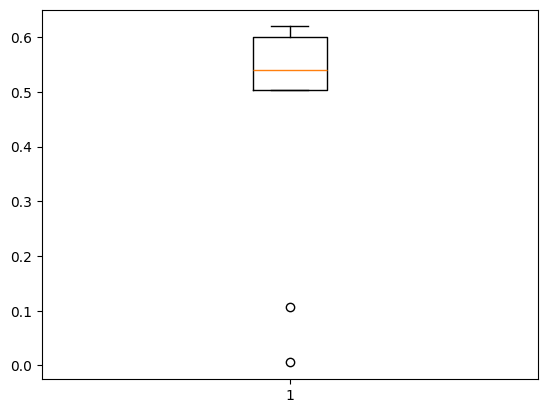

In [127]:
r_peaks, _ = find_peaks(ecg_f, distance=fs*0.6, height=np.mean(ecg_f))

plt.boxplot(ecg_f[r_peaks])

r_peaks = r_peaks[ecg_f[r_peaks] >= 0.15]
dataframe = pd.DataFrame(ecg_f[r_peaks])
dataframe.describe()



In [128]:
rr_intervals = np.diff(r_peaks) / fs 
heart_rate = 60 / rr_intervals
average_hr = np.mean(heart_rate)

print(f"Average heart rate: {average_hr:.2f} bpm")

Average heart rate: 47.36 bpm


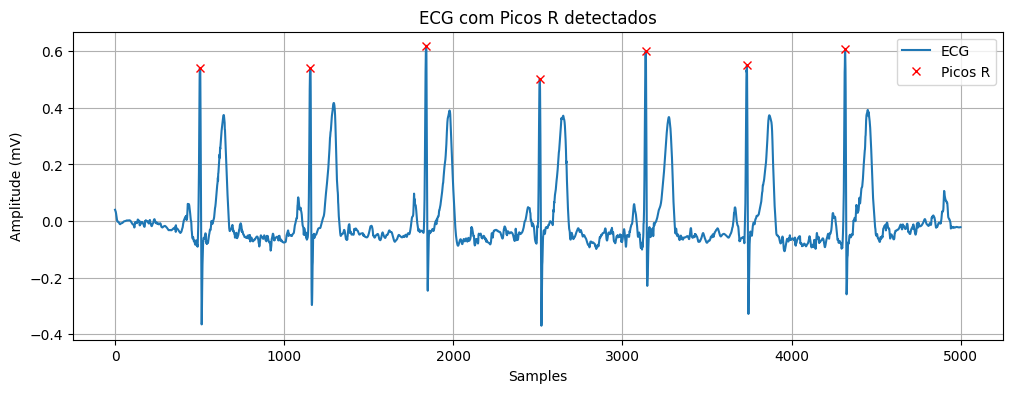

In [129]:
plt.figure(figsize=(12, 4))
plt.plot(ecg_f, label='ECG')
plt.plot(r_peaks, ecg_f[r_peaks], "rx", label='Picos R')
plt.title('ECG com Picos R detectados')
plt.xlabel('Samples')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.legend()
plt.show()

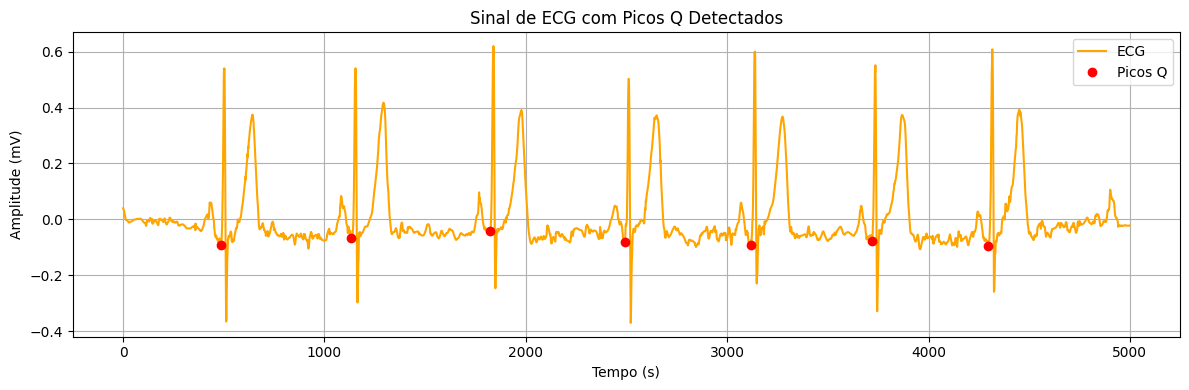

In [130]:
q_index = []
for i in range(len(r_peaks)):
    q_index.append(np.argmin(ecg_f[max(r_peaks[i]-20,0):r_peaks[i]]) + max(r_peaks[i]-20,0))


plt.figure(figsize=(12, 4))
plt.plot(ecg_f, label='ECG', color='orange')
plt.plot(q_index, ecg_f[q_index], 'ro', label='Picos Q')
plt.title('Sinal de ECG com Picos Q Detectados')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()